# SOM as a Nonlinear Projection Method

Kohonen argues that the SOM belongs to the family of **nonlinear projection methods**, alongside multidimensional scaling (MDS) and the Sammon mapping. This notebook tests that claim quantitatively by comparing DBGSOM against sklearn manifold methods on the MNIST dataset.

**Methods compared:** DBGSOM · Isomap · t-SNE · UMAP · **SOM→UMAP**  
**Metrics:** Trustworthiness · Continuity · Runtime

> **SOM→UMAP:** The trained SOM's `transform()` method encodes each sample as a sparse mixture of prototype weights. UMAP then projects these sparse codes to 2D — combining the SOM's topology-preserving quantization with UMAP's local structure preservation.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.manifold import trustworthiness
from umap import UMAP

from dbgsom.SomVQ import SomVQ

## Dataset

MNIST contains 28×28 greyscale images of handwritten digits (0–9), represented as 784-dimensional vectors. The full dataset has 70 000 samples; a stratified subsample of 10 000 is used here so that Isomap (O(n²)) remains tractable. Pixel values are normalised to [0, 1].


In [2]:
from sklearn.model_selection import train_test_split

try:
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X_full, y_full = mnist.data / 255.0, mnist.target.astype(int)
    # Stratified subsample — Isomap is O(n²); 10 000 keeps runtime tractable
    X, _, y, _ = train_test_split(
        X_full, y_full, train_size=10_000, stratify=y_full, random_state=42
    )
    print(f"MNIST  — Shape: {X.shape}  |  Classes: {np.unique(y)}")
except Exception as e:
    from sklearn.datasets import load_digits

    print(f"OpenML unreachable ({type(e).__name__}), falling back to Digits.")
    X, y = load_digits(return_X_y=True)
    print(f"Digits — Shape: {X.shape}  |  Classes: {np.unique(y)}")

MNIST  — Shape: (10000, 784)  |  Classes: [0 1 2 3 4 5 6 7 8 9]


## Train All Methods


In [4]:
# --- DBGSOM ---
from sklearn.manifold import TSNE, Isomap

t0 = time.perf_counter()
som = SomVQ(
    random_state=42,
    n_iter=500,
    verbose=False,
    spreading_factor=0.9,
)
som.fit(X)
t_som = time.perf_counter() - t0

bmu_indices = som.predict(X)
som_coords = np.array([som.neurons_[i] for i in bmu_indices], dtype=float)

# --- Isomap ---
t0 = time.perf_counter()
isomap_coords = Isomap(n_components=2, n_neighbors=10).fit_transform(X)
t_isomap = time.perf_counter() - t0

# --- UMAP ---
t0 = time.perf_counter()
umap_coords = UMAP(n_components=2, n_neighbors=5).fit_transform(X)
t_umap = time.perf_counter() - t0

# --- t-SNE ---
t0 = time.perf_counter()
tsne_coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)
t_tsne = time.perf_counter() - t0

# --- SOM → transform() → UMAP ---
t0 = time.perf_counter()
som_codes = som.transform(X)
som_umap_coords = UMAP(n_components=2, n_neighbors=5).fit_transform(som_codes)
t_som_umap = t_som + (time.perf_counter() - t0)

embeddings = {
    "DBGSOM": som_coords,
    "Isomap": isomap_coords,
    "t-SNE": tsne_coords,
    "UMAP": umap_coords,
    "SOM→UMAP": som_umap_coords,
}
runtimes = {
    "DBGSOM": t_som,
    "Isomap": t_isomap,
    "t-SNE": t_tsne,
    "UMAP": t_umap,
    "SOM→UMAP": t_som_umap,
}

print(f"{'Method':<12} {'Runtime (s)':>12}")
for name, t in runtimes.items():
    extra = f"  ({som.som_.number_of_nodes()} neurons)" if name == "DBGSOM" else ""
    print(f"{name:<12} {t:>12.3f}{extra}")

Method        Runtime (s)
DBGSOM              4.625  (103 neurons)
Isomap             24.660
t-SNE              36.936
UMAP               20.816
SOM→UMAP           13.304


## Trustworthiness & Continuity

**Trustworthiness** asks: are the k nearest neighbours in the embedding also close in the original space? (Precision)  
**Continuity** asks: are the k nearest neighbours in the original space also close in the embedding? (Recall)

Both metrics are from Venna & Kaski (2001). Continuity is computed by swapping the roles of `X` and `X_emb` in the trustworthiness formula.


In [5]:
def continuity(X, X_emb, n_neighbors):
    return trustworthiness(X_emb, X, n_neighbors=n_neighbors)


k_values = [5, 10, 20]
rows = []
for name, emb in embeddings.items():
    row = {"Method": name}
    for k in k_values:
        row[f"T (k={k})"] = round(trustworthiness(X, emb, n_neighbors=k), 4)
        row[f"C (k={k})"] = round(continuity(X, emb, n_neighbors=k), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
print(df.to_string())
df

          T (k=5)  C (k=5)  T (k=10)  C (k=10)  T (k=20)  C (k=20)
Method                                                            
DBGSOM     0.9362   0.9268    0.9375    0.9209    0.9380    0.9127
Isomap     0.7592   0.9634    0.7582    0.9594    0.7583    0.9480
t-SNE      0.9919   0.9794    0.9860    0.9721    0.9771    0.9629
UMAP       0.9695   0.9795    0.9659    0.9702    0.9611    0.9590
SOM→UMAP   0.9568   0.8804    0.9512    0.8691    0.9433    0.8556


,T (k=5),C (k=5),T (k=10),C (k=10),T (k=20),C (k=20)
Method,,,,,,
DBGSOM,0.9362,0.9268,0.9375,0.9209,0.9380,0.9127
Isomap,0.7592,0.9634,0.7582,0.9594,0.7583,0.9480
t-SNE,0.9919,0.9794,0.9860,0.9721,0.9771,0.9629
UMAP,0.9695,0.9795,0.9659,0.9702,0.9611,0.9590
SOM→UMAP,0.9568,0.8804,0.9512,0.8691,0.9433,0.8556


## 2D Scatter Plots

Each point is coloured by its true digit label. The SOM plot uses grid coordinates; overlapping points (multiple samples mapped to the same BMU) are expected.


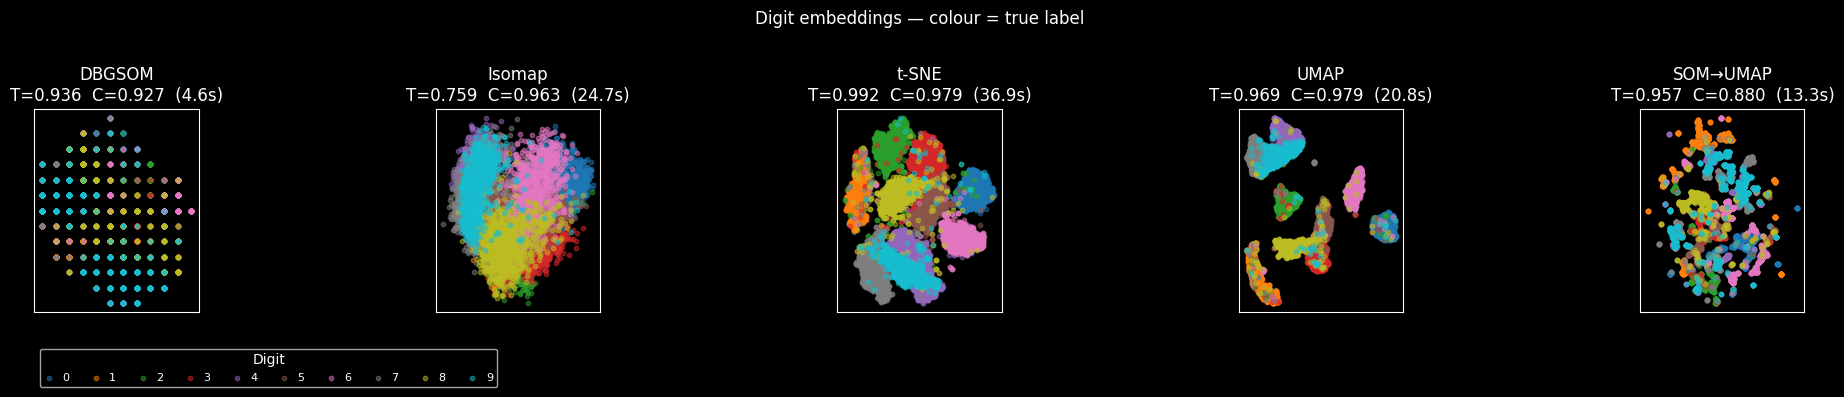

In [6]:
palette = sns.color_palette("tab10", n_colors=10)

n_methods = len(embeddings)
fig, axes = plt.subplots(1, n_methods, figsize=(3.6 * n_methods, 4))
for ax, (name, emb) in zip(axes, embeddings.items()):
    for digit in range(10):
        mask = y == digit
        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            color=palette[digit],
            s=10,
            alpha=0.5,
            label=str(digit),
        )
    t5 = trustworthiness(X, emb, n_neighbors=5)
    c5 = continuity(X, emb, n_neighbors=5)
    ax.set_title(f"{name}\nT={t5:.3f}  C={c5:.3f}  ({runtimes[name]:.1f}s)")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(
    title="Digit",
    bbox_to_anchor=(0, -0.15),
    loc="upper left",
    ncol=10,
    fontsize=8,
    handlelength=0.8,
)
plt.suptitle("Digit embeddings — colour = true label", y=1.02)
plt.tight_layout()
plt.show()

## Runtime Comparison


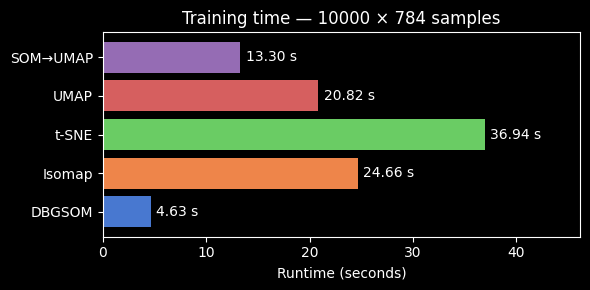

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
names = list(runtimes.keys())
times = list(runtimes.values())
bars = ax.barh(names, times, color=sns.color_palette("muted", len(names)))
ax.bar_label(bars, fmt="%.2f s", padding=4)
ax.set_xlabel("Runtime (seconds)")
ax.set_title(f"Training time — {X.shape[0]} × {X.shape[1]} samples")
ax.set_xlim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()

In [8]:
som

,spreading_factor,0.9
,random_state,42
,n_iter,500
,sigma_start,None
,sigma_end,None
,sigma_fine,None
,vertical_growth,False
,decay_function,'exponential'
,neighborhood_function,'gaussian'
,verbose,False
,coarse_training_frac,0.5
